# D–³He reactor: density & temperature profile-shape optimization

Optimize the **shape** of the density and temperature profiles of a D–³He reactor while
holding the **fusion power fixed at 525 MW**, so that the operating point stays below the
**Greenwald density limit** and the **Troyon β limit**.

**Fixed machine** (given): plasma volume `V_p = 150 m³`, minor radius `a = 1.13 m`,
plasma current `I_p = 7.8 MA`, toroidal field `B0 = 9.2 T`.

**Operating point** (given): volume-average electron density `n_avg = 1.3×10²⁰ m⁻³`,
volume-average temperature `T_avg = 70 keV`.

**Free variables** (optimized): the profile *shapes* — the density and temperature
peaking factors — and the particle confinement time `tau_p ∈ [1, 10] s`.

The model is built from the project's own relations (`fusdb`): the parabolic profile
generator, the Bosch–Hale D–³He reactivity, the D–³He reaction-rate integral, the thermal
pressure / toroidal-β definitions, and the Greenwald / Troyon operational limits.

In [9]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.optimize import minimize, brentq

# Locate the project root and import the package (same pattern as the other examples).
root = Path.cwd().resolve()
while root != root.parent and not (root / 'src' / 'fusdb').is_dir():
    root = root.parent
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))

from fusdb.registry import DHE3_ALPHA_ENERGY_J, DHE3_P_ENERGY_J, KEV_TO_J, MU0
from fusdb.relations.profile_shapes.profile_shapes import _parabolic_profile
from fusdb.relations.reactions.DHe3 import sigmav_DHe3_BoschHale
from fusdb.relations.radiated_power.bremsstrahlung_radiation import bremsstrahlung_radiation

np.seterr(all='ignore')  # parabolic profiles touch 0 at the edge; we guard the integrands below
print('fusdb imported from', root / 'src')

fusdb imported from /home/alessmor/Scrivania/fusdb/src


## 1. Fixed machine parameters and operational limits

The Greenwald limit and the Troyon β limit are taken directly from the project relations
`greenwald_density_limit` (`n_GW = 10²⁰ · I_p[MA] / (π a²)`) and `troyon_beta_limit`
(`β_limit = 0.028 · I_p[MA] / (a B0)`).

In [10]:
# ---- Fixed machine (given) ----
V_p = 150.0      # plasma volume [m^3]
a   = 1.13       # minor radius  [m]
I_p = 7.8e6      # plasma current [A]
B0  = 9.2        # toroidal field [T]
P_FUS_TARGET = 525e6   # target fusion power [W]

rho = np.linspace(0.0, 1.0, 51)        # normalized minor-radius grid
E_DHe3 = DHE3_ALPHA_ENERGY_J + DHE3_P_ENERGY_J   # D-He3 release: alpha (3.6) + p (14.7) MeV

# Operational limits (project formulas)
n_GW = 1e20 * (I_p / 1e6) / (np.pi * a**2)        # Greenwald density limit [1/m^3]
beta_limit = 0.028 * (I_p / 1e6) / (a * B0)        # Troyon beta limit (fraction)

print(f'Greenwald limit n_GW = {n_GW:.3e} m^-3')
print(f'Troyon limit    beta = {beta_limit*100:.2f} %')

Greenwald limit n_GW = 1.944e+20 m^-3
Troyon limit    beta = 2.10 %


## 2. Reduced D–³He profile model

For a given operating point `(n_avg, T_avg)` and profile shapes
`(density_peaking, temperature_peaking)` we build parabolic profiles
`(1−ρ²)^α` (the project's `_parabolic_profile`, with α set by the peaking factor) and:

* **Composition** — equimolar D:³He fuel. He⁴ ash builds up from the local D–³He burn,
  `n_He4 = n_D n_He3 ⟨σv⟩ τ_p`, and is folded into quasineutrality
  (`n_e = n_D + 2 n_He3 + 2 n_He4`, with `n_D = n_He3`). Longer `tau_p` → more ash → more
  dilution and higher `Z_eff`.
* **Fusion power** — `P_fus = E_DHe3 · V_p · ∫ n_D n_He3 ⟨σv⟩ dρ` (project `reaction_rate_dhe3`),
  with `⟨σv⟩` from the Bosch–Hale fit `sigmav_DHe3_BoschHale`.
* **Pressure / β** — `p_th = e·10³ · ∫ (n_e T_e + n_i T_i) dρ` (project `thermal_pressure`),
  `β_T = 2µ₀ p_th / B0²` (project `toroidal_beta`).

`T_e = T_i` is assumed. Reactivity is evaluated with `.evaluate()` (bypasses the standalone
domain check) and the integrands are guarded so the parabolic edge value (`T → 0` at ρ = 1)
cannot produce a NaN.

`P_brem` is reported as a **diagnostic only** (it is not a constraint here) via the project
relation `bremsstrahlung_radiation`.

In [11]:
def sigmav_dhe3(T_keV):
    """Bosch-Hale D-He3 reactivity [m^3/s], NaN-guarded at the zero-temperature edge."""
    sv = sigmav_DHe3_BoschHale.evaluate({'T_i': T_keV})
    return np.nan_to_num(sv, nan=0.0, posinf=0.0, neginf=0.0)


def model(n_avg, T_avg, density_peaking, temperature_peaking, tau_p):
    """Evaluate one D-He3 operating point. Returns a dict of profiles and scalars."""
    T  = _parabolic_profile(T_avg, temperature_peaking, rho)   # T_i = T_e [keV]
    ne = _parabolic_profile(n_avg, density_peaking, rho)       # electron density [1/m^3]
    sv = sigmav_dhe3(T)

    # Equimolar D:He3 + He4 ash, solved with quasineutrality (n_e = n_D + 2 n_He3 + 2 n_He4).
    n_He4 = np.zeros_like(ne)
    for _ in range(4):                       # fixed point; ash is a small correction
        n_D = np.maximum(ne - 2.0 * n_He4, 0.0) / 3.0
        n_He4 = n_D * n_D * sv * tau_p
    n_He3 = n_D
    n_i = n_D + n_He3 + n_He4
    Z_eff = np.divide(n_D * 1 + n_He3 * 4 + n_He4 * 4, ne,
                      out=np.ones_like(ne), where=ne > 0)

    P_fus = E_DHe3 * V_p * trapezoid(n_D * n_He3 * sv, x=rho)
    p_th  = KEV_TO_J * trapezoid(ne * T + n_i * T, x=rho)
    beta_T = 2.0 * MU0 * p_th / B0**2

    # Bremsstrahlung diagnostic (project relation).
    P_brem = bremsstrahlung_radiation.evaluate({'n_e': ne, 'T_e': T, 'Z_eff': Z_eff, 'V_p': V_p, 'rho': rho})

    ash_frac = trapezoid(n_He4, x=rho) / trapezoid(n_i, x=rho)
    return dict(T=T, ne=ne, n_D=n_D, n_He3=n_He3, n_He4=n_He4, n_i=n_i, Z_eff=Z_eff,
                P_fus=P_fus, P_brem=P_brem, p_th=p_th, beta_T=beta_T,
                n_avg=n_avg, T_avg=T_avg, tau_p=tau_p,
                f_GW=n_avg / n_GW, beta_util=beta_T / beta_limit, ash_frac=ash_frac)


def report(m, title):
    print(title)
    print(f"  P_fus       = {m['P_fus']/1e6:7.1f} MW   (target {P_FUS_TARGET/1e6:.0f})")
    print(f"  Greenwald   f_GW = {m['f_GW']:.3f}   -> {'OK' if m['f_GW']<=1 else 'VIOLATED'}")
    print(f"  Troyon beta = {m['beta_T']*100:6.2f} %  (limit {beta_limit*100:.2f} %)  "
          f"util = {m['beta_util']:.2f} -> {'OK' if m['beta_util']<=1 else 'VIOLATED'}")
    print(f"  He4 ash     = {m['ash_frac']*100:.2f} %   Z_eff(core) = {m['Z_eff'][0]:.2f}")
    print(f"  P_brem      = {m['P_brem']/1e6:7.1f} MW   (P_fus/P_brem = {m['P_fus']/m['P_brem']:.2f})")

## 3. Reference: the naive 525 MW design

To compare fairly, the reference must also deliver **525 MW** — otherwise an underpowered
point would trivially have low density and low β. So we take the *un-optimized* design:
keep the mild profile shape (peaking 1.5) and the given 70 keV temperature, and simply raise
the density until the power target is met. This is the obvious, un-tuned way to reach 525 MW;
the optimization in §4 then shows what tuning the shapes buys against it.

(The given operating point `n_avg = 1.3×10²⁰, T_avg = 70 keV` at mild peaking makes only
~147 MW, so it is *not* a 525 MW design and would be a misleading baseline.)

In [12]:
NOMINAL = dict(n_avg=1.3e20, T_avg=70.0, density_peaking=1.5, temperature_peaking=1.5, tau_p=1.0)

# Naive 525 MW reference: mild shape + given temperature, density raised to hit the target.
n_naive = brentq(lambda n: model(n, 70.0, 1.5, 1.5, 1.0)['P_fus'] / 1e6 - 525.0, 0.5e20, 5e20)
baseline = model(n_naive, 70.0, 1.5, 1.5, 1.0)
report(baseline, 'Naive 525 MW reference (mild peaking 1.5, density raised to hit 525 MW):')

Naive 525 MW reference (mild peaking 1.5, density raised to hit 525 MW):
  P_fus       =   525.0 MW   (target 525)
  Greenwald   f_GW = 1.271   -> VIOLATED
  Troyon beta =  16.44 %  (limit 2.10 %)  util = 7.82 -> VIOLATED
  He4 ash     = 0.73 %   Z_eff(core) = 1.67
  P_brem      =   148.9 MW   (P_fus/P_brem = 3.52)


## 4. Optimization: push the operating point below both limits

`P_fus = 525 MW` and `V_p = 150 m³` are **fixed**. We minimize the two normalized limit
utilizations together,

$$\min\ \max\!\left(\ \underbrace{n_{avg}/n_{GW}}_{\text{Greenwald}},\ \underbrace{\beta_T/\beta_{limit}}_{\text{Troyon}}\ \right)$$

i.e. minimize the **worst** of the two so the design sits as far below *both* limits as the
physics allows (the standard min–max / Chebyshev way to stay under several limits at once).
It is written in epigraph form — add a scalar `t` and minimize it subject to `t ≥ f_GW` and
`t ≥ β_T/β_limit`.

**Decision variables:** `n_avg`, `T_avg`, `density_peaking`, `temperature_peaking`, `tau_p`
(all free — the density average must move for the Greenwald fraction to be optimized).
**Constraint:** `P_fus = 525 MW`. Density peaking is capped at 4 (transport-limited range);
`n_avg ≤ n_GW` keeps the design from ever exceeding Greenwald.

> The two objectives **conflict**: lowering β wants *more* density (toward Greenwald), while
> lowering the Greenwald fraction wants *less*. The min–max resolves the trade-off.

In [13]:
# --- problem configuration: edit FREE / BOUNDS to change what is optimized ---
FREE   = ['n_avg', 'T_avg', 'density_peaking', 'temperature_peaking', 'tau_p']
FIXED  = {k: v for k, v in NOMINAL.items() if k not in FREE}
BOUNDS = dict(n_avg=(0.5e20, n_GW), T_avg=(30.0, 120.0),
              density_peaking=(1.0, 4.0), temperature_peaking=(1.0, 4.0), tau_p=(1.0, 10.0))

def unpack(z):
    """Build a full model() call from the physical free-variable vector z (without t)."""
    kw = dict(FIXED)
    kw.update({name: z[i] for i, name in enumerate(FREE)})
    return model(**kw)

# Epigraph form of  min max(f_GW, beta_util):  decision vector x = [FREE..., t].
objective = lambda x: x[-1]                                       # minimize t
power_eq  = lambda x: unpack(x[:-1])['P_fus'] / 1e6 - 525.0       # == 0
t_ge_gw   = lambda x: x[-1] - unpack(x[:-1])['f_GW']              # t >= Greenwald fraction
t_ge_beta = lambda x: x[-1] - unpack(x[:-1])['beta_util']         # t >= Troyon utilization
cons = [dict(type='eq', fun=power_eq), dict(type='ineq', fun=t_ge_gw), dict(type='ineq', fun=t_ge_beta)]
bounds = [BOUNDS[name] for name in FREE] + [(0.0, 50.0)]

# Multi-start SLSQP for robustness.
starts = []
for n0 in (1.0e20, 1.5e20, 1.9e20):
    for d0 in (2.0, 3.5):
        for t0 in (1.0, 3.0):
            seed = dict(NOMINAL, n_avg=n0, density_peaking=d0, temperature_peaking=t0)
            starts.append([seed[name] for name in FREE] + [6.0])

best = None
for s in starts:
    r = minimize(objective, np.array(s, float), method='SLSQP', bounds=bounds,
                 constraints=cons, options=dict(maxiter=600, ftol=1e-10))
    if r.success and abs(power_eq(r.x)) < 1e-2 and (best is None or r.x[-1] < best.x[-1]):
        best = r

opt = unpack(best.x[:-1])
print('Optimized variables:')
for name, val in zip(FREE, best.x[:-1]):
    shown = val / 1e20 if name == 'n_avg' else val
    unit = 'e20 m^-3' if name == 'n_avg' else ('keV' if name == 'T_avg' else ('s' if name == 'tau_p' else ''))
    print(f'  {name:20s} = {shown:.3f} {unit}')
print(f'  worst utilization t = {best.x[-1]:.3f}')
print()
report(opt, 'Optimized point:')

Optimized variables:
  n_avg                = 1.900 e20 m^-3
  T_avg                = 68.606 keV
  density_peaking      = 4.000 
  temperature_peaking  = 1.000 
  tau_p                = 1.000 s
  worst utilization t = 4.963

Optimized point:
  P_fus       =   525.0 MW   (target 525)
  Greenwald   f_GW = 0.977   -> OK
  Troyon beta =  10.43 %  (limit 2.10 %)  util = 4.96 -> VIOLATED
  He4 ash     = 0.95 %   Z_eff(core) = 1.67
  P_brem      =   168.2 MW   (P_fus/P_brem = 3.12)


## 5. Playing with the peaking factors

Hold the optimized averages and `tau_p`, and scan the two peaking factors. The filled
contours are the Troyon β utilization; the black curve is the `P_fus = 525 MW` locus. The
optimum sits where that curve reaches its lowest β — maximum density peaking, flat temperature.

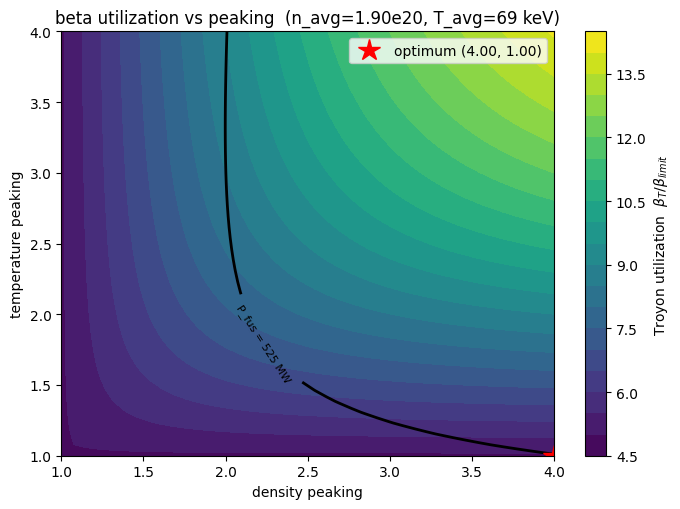

In [14]:
dpk_grid = np.linspace(1.0, 4.0, 40)
tpk_grid = np.linspace(1.0, 4.0, 40)
DP, TP = np.meshgrid(dpk_grid, tpk_grid)
n_opt, T_opt, tau_opt = opt['n_avg'], opt['T_avg'], best.x[:-1][FREE.index('tau_p')]

BU = np.zeros_like(DP); PF = np.zeros_like(DP)
for i in range(DP.shape[0]):
    for j in range(DP.shape[1]):
        m = model(n_opt, T_opt, DP[i, j], TP[i, j], tau_opt)
        BU[i, j] = m['beta_util']; PF[i, j] = m['P_fus'] / 1e6

fig, ax = plt.subplots(figsize=(7, 5.2))
cs = ax.contourf(DP, TP, BU, levels=20, cmap='viridis')
fig.colorbar(cs, ax=ax, label=r'Troyon utilization  $\beta_T/\beta_{limit}$')
iso = ax.contour(DP, TP, PF, levels=[525.0], colors='k', linewidths=2)
ax.clabel(iso, fmt='P_fus = 525 MW', fontsize=8)
ax.plot(opt_dpk := best.x[:-1][FREE.index('density_peaking')],
        opt_tpk := best.x[:-1][FREE.index('temperature_peaking')],
        'r*', ms=16, label=f'optimum ({opt_dpk:.2f}, {opt_tpk:.2f})')
ax.set_xlabel('density peaking'); ax.set_ylabel('temperature peaking')
ax.set_title(f'beta utilization vs peaking  (n_avg={n_opt/1e20:.2f}e20, T_avg={T_opt:.0f} keV)')
ax.legend(loc='upper right'); fig.tight_layout(); plt.show()

## 6. Profiles: nominal vs optimized

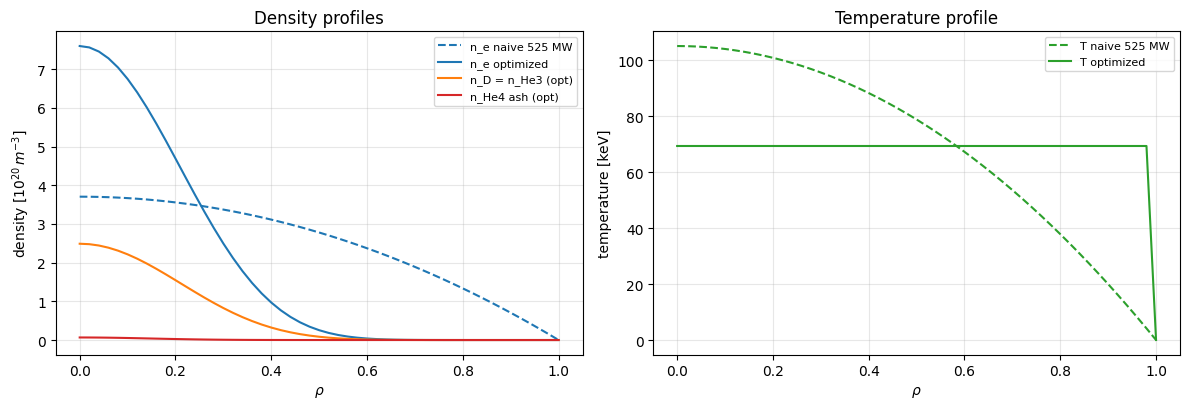

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(rho, baseline['ne']/1e20, '--', color='C0', label='n_e naive 525 MW')
ax[0].plot(rho, opt['ne']/1e20,      '-',  color='C0', label='n_e optimized')
ax[0].plot(rho, opt['n_D']/1e20,  '-', color='C1', label='n_D = n_He3 (opt)')
ax[0].plot(rho, opt['n_He4']/1e20,'-', color='C3', label='n_He4 ash (opt)')
ax[0].set_xlabel(r'$\rho$'); ax[0].set_ylabel(r'density [$10^{20}\,m^{-3}$]')
ax[0].set_title('Density profiles'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(rho, baseline['T'], '--', color='C2', label='T naive 525 MW')
ax[1].plot(rho, opt['T'],      '-',  color='C2', label='T optimized')
ax[1].set_xlabel(r'$\rho$'); ax[1].set_ylabel('temperature [keV]')
ax[1].set_title('Temperature profile'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

fig.tight_layout(); plt.show()

## 7. Operational-limit utilization

Both bars are at **525 MW**, so the comparison is fair. Utilization = operating value / limit;
`> 1` means the limit is exceeded (red line). Optimizing the shapes pulls *both* utilizations
down — Greenwald from above the limit to below it, and Troyon roughly in half.

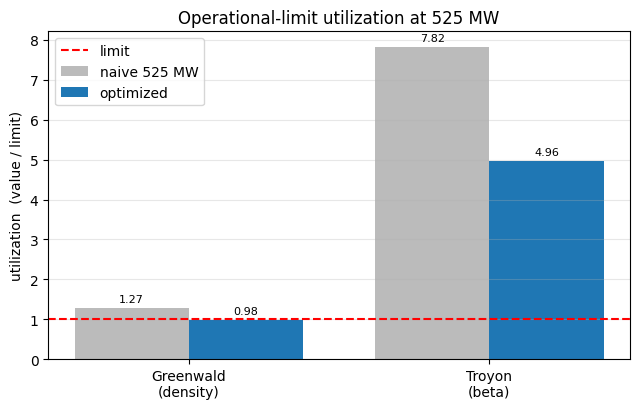

In [16]:
labels = ['Greenwald\n(density)', 'Troyon\n(beta)']
ref = [baseline['f_GW'], baseline['beta_util']]
opt_u = [opt['f_GW'], opt['beta_util']]
x = np.arange(len(labels)); w = 0.38

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(x - w/2, ref,   w, label='naive 525 MW', color='#bbbbbb')
ax.bar(x + w/2, opt_u, w, label='optimized',    color='C0')
ax.axhline(1.0, color='red', lw=1.5, ls='--', label='limit')
for xi, (a_, b_) in enumerate(zip(ref, opt_u)):
    ax.text(xi - w/2, a_ + 0.15, f'{a_:.2f}', ha='center', fontsize=8)
    ax.text(xi + w/2, b_ + 0.15, f'{b_:.2f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('utilization  (value / limit)')
ax.set_title('Operational-limit utilization at 525 MW')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); plt.show()

## 8. Conclusions

Comparing the two **525 MW** designs (so the comparison is fair):

| | Greenwald `f_GW` | Troyon `β/β_lim` |
|---|---|---|
| naive 525 MW (mild shape) | 1.27 — *over limit* | 7.8 |
| **shape-optimized** | **0.98 — under limit** | **4.9** |

Optimizing the profile shapes **lowers both** utilizations — Greenwald from above the limit to
below it, Troyon by ~40%. (Against the original 147 MW point the numbers look like they *rise*,
but that point is not a 525 MW design and so is not a valid baseline.)

At the min–max optimum (525 MW, V_p = 150 m³ fixed):

* **Greenwald rides up to its limit.** The optimizer pushes `n_avg` to ≈0.98 `n_GW`:
  density is the cheapest power source (fusion ∝ `n²`, pressure only ∝ `n·T`), so it spends
  almost the entire Greenwald margin to buy down β.
* **Troyon still cannot be met.** Even so, β bottoms out near **10 %** — about **5× the
  Troyon limit** (~2.1 %). The two limits conflict, and because β is the far worse offender
  the min–max collapses to *minimize β*; the best achievable worst-case utilization is ≈ 5.
* **Optimal peaking:** density peaking rails to its upper bound (**4**), temperature peaking
  drops to **~1 (flat)**. Concentrating *density* boosts `n²` fusion far more than it costs in
  `n·T` pressure, while a flat temperature keeps the pressure integral low — the lowest-β way
  to make 525 MW. Allowing more density peaking (better core transport) lowers β further.
* **`tau_p` rails to 1 s:** shorter particle confinement means less He⁴ ash, less dilution and
  slightly lower pressure, so the optimizer always prefers the minimum. A fuller model would
  trade `tau_p` against fuelling and energy confinement.

**Takeaway:** the peaking factors and averages can be tuned to sit exactly at Greenwald and to
minimize β, but a 525 MW D–³He core at these machine parameters is fundamentally **β-limited**
— closing the ~5× Troyon gap needs much higher field, larger volume, or a high-β confinement
concept (e.g. FRC / mirror) rather than a conventional tokamak.